# CDC PLACES - Health Data Exploratory Analysis

**Data Source:**
- `cdc_places_wide`: 1,174 rows - ZCTA-level health measures

**Objectives:**
1. Understand health measure coverage across NJ ZCTAs
2. Identify geographic health disparities
3. Analyze correlations between health measures
4. Identify areas of concern for public health interventions

In [11]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Connect to database
db_path = Path('../data/db/nj_pipeline.duckdb')

# Close any existing connections in DataSpell, then use:
conn = duckdb.connect(str(db_path), read_only=True)
print(f"Connected to: {db_path}")

Connected to: ../data/db/nj_pipeline.duckdb


In [12]:
# Schema information
print("=" * 60)
print("CDC PLACES SCHEMA")
print("=" * 60)
display(conn.execute("DESCRIBE cdc_places_wide").df())

CDC PLACES SCHEMA


,column_name,column_type,null,key,default,extra
0,zcta,VARCHAR,YES,None,None,None
1,location_name,VARCHAR,YES,None,None,None
2,year,BIGINT,YES,None,None,None
3,access2,DOUBLE,YES,None,None,None
4,arthritis,DOUBLE,YES,None,None,None
5,bphigh,DOUBLE,YES,None,None,None
6,cancer,DOUBLE,YES,None,None,None
7,casthma,DOUBLE,YES,None,None,None
8,chd,DOUBLE,YES,None,None,None
9,checkup,DOUBLE,YES,None,None,None


In [13]:
# dataframe
df = conn.execute("SELECT * FROM cdc_places_wide").df()

In [14]:
df

,zcta,location_name,year,access2,arthritis,bphigh,cancer,casthma,chd,checkup,...,diabetes,ghlth,highchol,lpa,mhlth,obesity,phlth,sleep,stroke,teethlost
0,07001,07001,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0,NaN,10.9
1,07001,07001,2023,12.5,18.4,31.8,5.1,8.7,4.5,76.6,...,10.8,18.4,35.9,26.9,15.6,32.1,11.4,NaN,2.6,NaN
2,07002,07002,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.9,NaN,11.3
3,07002,07002,2023,13.6,19.8,30.9,6.4,9.3,5.4,76.6,...,10.6,19.0,37.8,27.9,15.8,29.1,13.6,NaN,3.0,NaN
4,07003,07003,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.0,NaN,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,08901,08901,2023,24.5,14.5,27.4,2.9,9.7,4.3,72.0,...,10.9,27.3,30.2,35.1,20.9,36.2,14.0,NaN,2.6,NaN
1170,08902,08902,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.7,NaN,9.2
1171,08902,08902,2023,11.7,19.5,32.4,5.6,8.7,4.7,78.4,...,11.4,17.8,37.2,25.8,14.5,31.3,11.2,NaN,2.7,NaN
1172,08904,08904,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.2,NaN,7.3


In [15]:
# Data coverage
coverage = conn.execute("""
    SELECT 
        COUNT(*) as num_records,
        COUNT(DISTINCT zcta) as num_zctas,
        MIN(year) as earliest_year,
        MAX(year) as latest_year
    FROM cdc_places_wide
""").df()

print("\nData Coverage:")
display(coverage)


Data Coverage:


,num_records,num_zctas,earliest_year,latest_year
0,1174,587,2022,2023


In [16]:
# Get all data
zcta_data = conn.execute("""
    SELECT * FROM cdc_places_wide
    ORDER BY zcta, year
""").df()

print(f"\nTotal records: {len(zcta_data)}")
print(f"Unique ZCTAs: {zcta_data['zcta'].nunique()}")
print(f"Years: {sorted(zcta_data['year'].unique())}")
print("\nSample data:")
display(zcta_data.head())


Total records: 1174
Unique ZCTAs: 587
Years: [np.int64(2022), np.int64(2023)]

Sample data:


,zcta,location_name,year,access2,arthritis,bphigh,cancer,casthma,chd,checkup,...,diabetes,ghlth,highchol,lpa,mhlth,obesity,phlth,sleep,stroke,teethlost
0,07001,07001,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0,NaN,10.9
1,07001,07001,2023,12.5,18.4,31.8,5.1,8.7,4.5,76.6,...,10.8,18.4,35.9,26.9,15.6,32.1,11.4,NaN,2.6,NaN
2,07002,07002,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.9,NaN,11.3
3,07002,07002,2023,13.6,19.8,30.9,6.4,9.3,5.4,76.6,...,10.6,19.0,37.8,27.9,15.8,29.1,13.6,NaN,3.0,NaN
4,07003,07003,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.0,NaN,8.6


## 2. Available Health Measures

In [17]:
# Get list of health measure columns
id_cols = ['zcta', 'location_name', 'year']
health_measures = [col for col in zcta_data.columns if col not in id_cols]

print(f"\nTotal health measures available: {len(health_measures)}")
print("\nHealth Measures:")
for i, measure in enumerate(sorted(health_measures), 1):
    print(f"  {i:2d}. {measure}")


Total health measures available: 22

Health Measures:
   1. access2
   2. arthritis
   3. bphigh
   4. cancer
   5. casthma
   6. chd
   7. checkup
   8. cholscreen
   9. copd
  10. csmoking
  11. dental
  12. depression
  13. diabetes
  14. ghlth
  15. highchol
  16. lpa
  17. mhlth
  18. obesity
  19. phlth
  20. sleep
  21. stroke
  22. teethlost


In [18]:
# Data completeness by measure
completeness_data = []
for measure in health_measures:
    non_null = zcta_data[measure].notna().sum()
    pct = (non_null / len(zcta_data)) * 100
    completeness_data.append({
        'measure': measure,
        'non_null_count': non_null,
        'pct_complete': round(pct, 1)
    })

completeness_df = pd.DataFrame(completeness_data).sort_values('pct_complete', ascending=False)
print("\nData Completeness:")
display(completeness_df)


Data Completeness:


,measure,non_null_count,pct_complete
0,access2,587,50.0
1,arthritis,587,50.0
20,stroke,587,50.0
19,sleep,587,50.0
18,phlth,587,50.0
17,obesity,587,50.0
16,mhlth,587,50.0
15,lpa,587,50.0
14,highchol,587,50.0
13,ghlth,587,50.0


## 3. Focus on Latest Year

In [19]:
# Get latest year with most complete data
latest_year = zcta_data['year'].max()
latest_data = zcta_data[zcta_data['year'] == latest_year].copy()

print(f"\nAnalyzing data for year: {latest_year}")
print(f"ZCTAs in {latest_year}: {len(latest_data)}")


Analyzing data for year: 2023
ZCTAs in 2023: 587


## 4. Key Chronic Disease Measures

In [20]:
# Focus on key chronic disease measures
key_measures = {
    'obesity': 'Obesity',
    'diabetes': 'Diabetes', 
    'bphigh': 'High Blood Pressure',
    'chd': 'Coronary Heart Disease',
    'csmoking': 'Current Smoking',
    'depression': 'Depression',
    'mhlth': 'Mental Health Not Good',
    'lpa': 'No Leisure Physical Activity'
}

# Check which measures are available
available_measures = {k: v for k, v in key_measures.items() if k in latest_data.columns}
print(f"\nAvailable key measures: {len(available_measures)}")
for code, name in available_measures.items():
    print(f"  • {code}: {name}")


Available key measures: 8
  • obesity: Obesity
  • diabetes: Diabetes
  • bphigh: High Blood Pressure
  • chd: Coronary Heart Disease
  • csmoking: Current Smoking
  • depression: Depression
  • mhlth: Mental Health Not Good
  • lpa: No Leisure Physical Activity


In [21]:
# Summary statistics for key measures
if available_measures:
    summary_stats = latest_data[list(available_measures.keys())].describe().T
    summary_stats['measure_name'] = summary_stats.index.map(available_measures)
    summary_stats = summary_stats[['measure_name', 'count', 'mean', '50%', 'min', 'max']]
    summary_stats.columns = ['Measure', 'N', 'Mean %', 'Median %', 'Min %', 'Max %']
    
    print(f"\nHealth Measure Statistics Across NJ ZCTAs ({latest_year}):")
    display(summary_stats.round(1))


Health Measure Statistics Across NJ ZCTAs (2023):


,Measure,N,Mean %,Median %,Min %,Max %
obesity,Obesity,587.0,28.5,28.2,12.1,45.4
diabetes,Diabetes,587.0,10.2,9.8,0.9,20.0
bphigh,High Blood Pressure,587.0,32.6,32.3,6.4,49.4
chd,Coronary Heart Disease,587.0,5.6,5.5,0.5,12.1
csmoking,Current Smoking,587.0,10.8,10.3,3.3,29.8
depression,Depression,587.0,15.9,15.8,9.1,24.0
mhlth,Mental Health Not Good,587.0,14.8,14.5,8.0,25.3
lpa,No Leisure Physical Activity,587.0,23.0,22.0,11.5,47.4


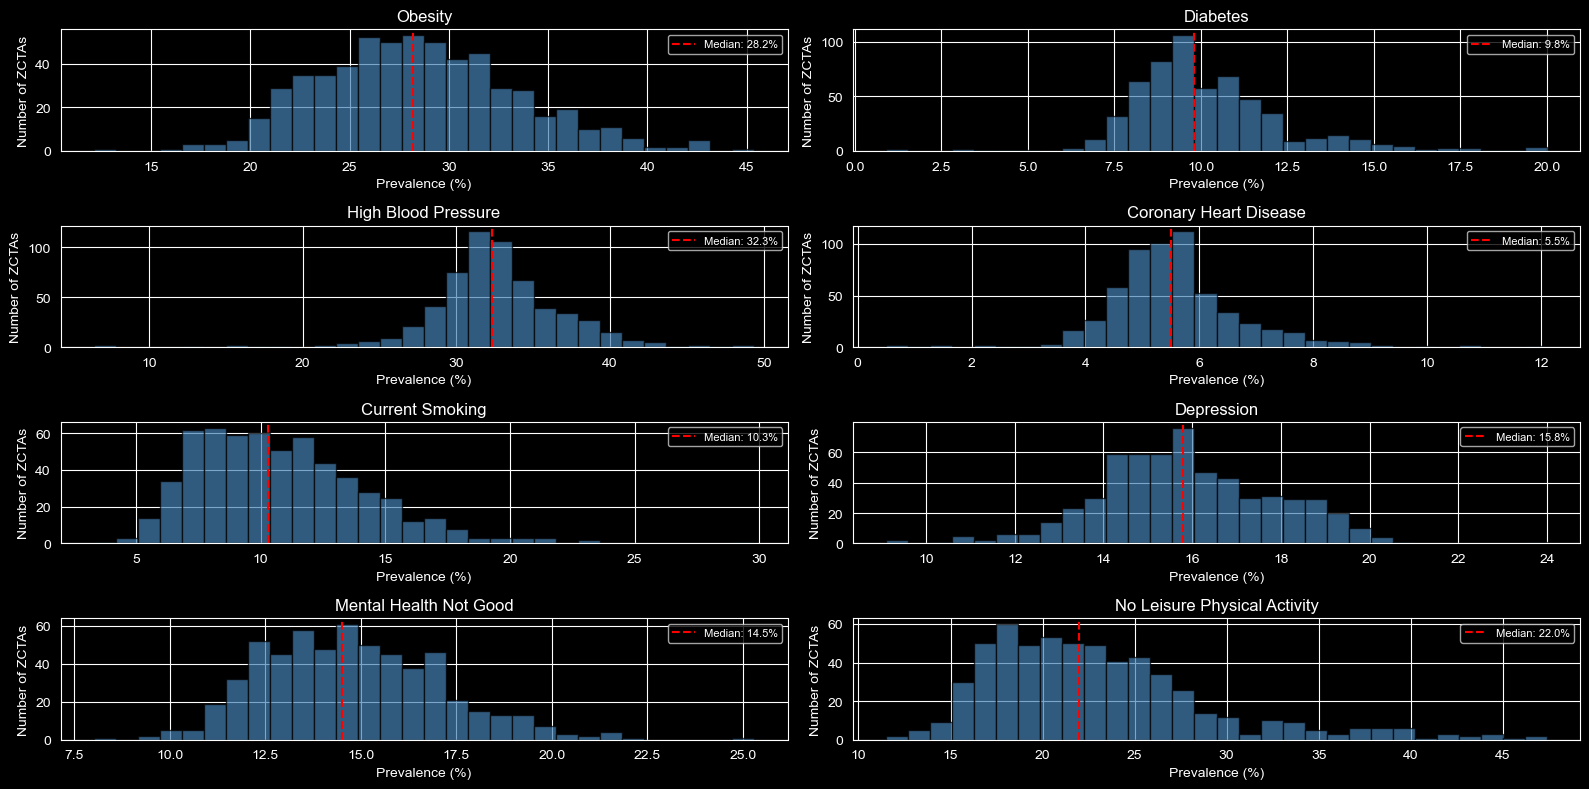

In [22]:
# Distribution plots for key measures
if available_measures and len(available_measures) >= 4:
    fig, axes = plt.subplots(4, 2, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, (measure_code, measure_name) in enumerate(list(available_measures.items())[:8]):
        if measure_code in latest_data.columns:
            data = latest_data[measure_code].dropna()
            if len(data) > 0:
                axes[idx].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
                axes[idx].axvline(data.median(), color='red', linestyle='--', 
                                 label=f'Median: {data.median():.1f}%')
                axes[idx].set_xlabel('Prevalence (%)')
                axes[idx].set_ylabel('Number of ZCTAs')
                axes[idx].set_title(measure_name)
                axes[idx].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

## 5. Geographic Disparities

In [23]:
# Best and worst performing ZCTAs for each measure
if available_measures:
    print("\nHealthiest ZCTAs (Lowest Prevalence):")
    print("=" * 70)
    
    for measure_code, measure_name in list(available_measures.items())[:4]:
        if measure_code in latest_data.columns:
            best = latest_data.nsmallest(5, measure_code)[['zcta', measure_code]]
            print(f"\n{measure_name}:")
            for _, row in best.iterrows():
                print(f"  ZCTA {row['zcta']}: {row[measure_code]:.1f}%")


Healthiest ZCTAs (Lowest Prevalence):

Obesity:
  ZCTA 08544: 12.1%
  ZCTA 08550: 15.9%
  ZCTA 07310: 16.8%
  ZCTA 07311: 17.0%
  ZCTA 08561: 17.6%

Diabetes:
  ZCTA 08544: 0.9%
  ZCTA 08240: 1.0%
  ZCTA 07311: 2.9%
  ZCTA 08641: 3.2%
  ZCTA 07310: 4.0%

High Blood Pressure:
  ZCTA 08544: 6.4%
  ZCTA 08240: 7.5%
  ZCTA 07311: 13.0%
  ZCTA 07310: 15.0%
  ZCTA 08641: 15.1%

Coronary Heart Disease:
  ZCTA 08544: 0.5%
  ZCTA 08240: 0.6%
  ZCTA 07311: 1.2%
  ZCTA 08641: 1.3%
  ZCTA 07310: 1.5%


In [24]:
if available_measures:
    print("\nZCTAs with Highest Health Burden:")
    print("=" * 70)
    
    for measure_code, measure_name in list(available_measures.items())[:4]:
        if measure_code in latest_data.columns:
            worst = latest_data.nlargest(5, measure_code)[['zcta', measure_code]]
            print(f"\n{measure_name}:")
            for _, row in worst.iterrows():
                print(f"  ZCTA {row['zcta']}: {row[measure_code]:.1f}%")


ZCTAs with Highest Health Burden:

Obesity:
  ZCTA 08320: 45.4%
  ZCTA 08302: 42.9%
  ZCTA 08103: 42.8%
  ZCTA 07114: 42.7%
  ZCTA 08327: 42.4%

Diabetes:
  ZCTA 08103: 20.0%
  ZCTA 08608: 20.0%
  ZCTA 07114: 19.8%
  ZCTA 08401: 19.5%
  ZCTA 07505: 19.1%

High Blood Pressure:
  ZCTA 08759: 49.4%
  ZCTA 07939: 49.0%
  ZCTA 08321: 47.1%
  ZCTA 08045: 46.5%
  ZCTA 08757: 45.4%

Coronary Heart Disease:
  ZCTA 08759: 12.1%
  ZCTA 08321: 10.9%
  ZCTA 08757: 10.8%
  ZCTA 07939: 10.1%
  ZCTA 08212: 9.3%


## 6. Correlation Analysis

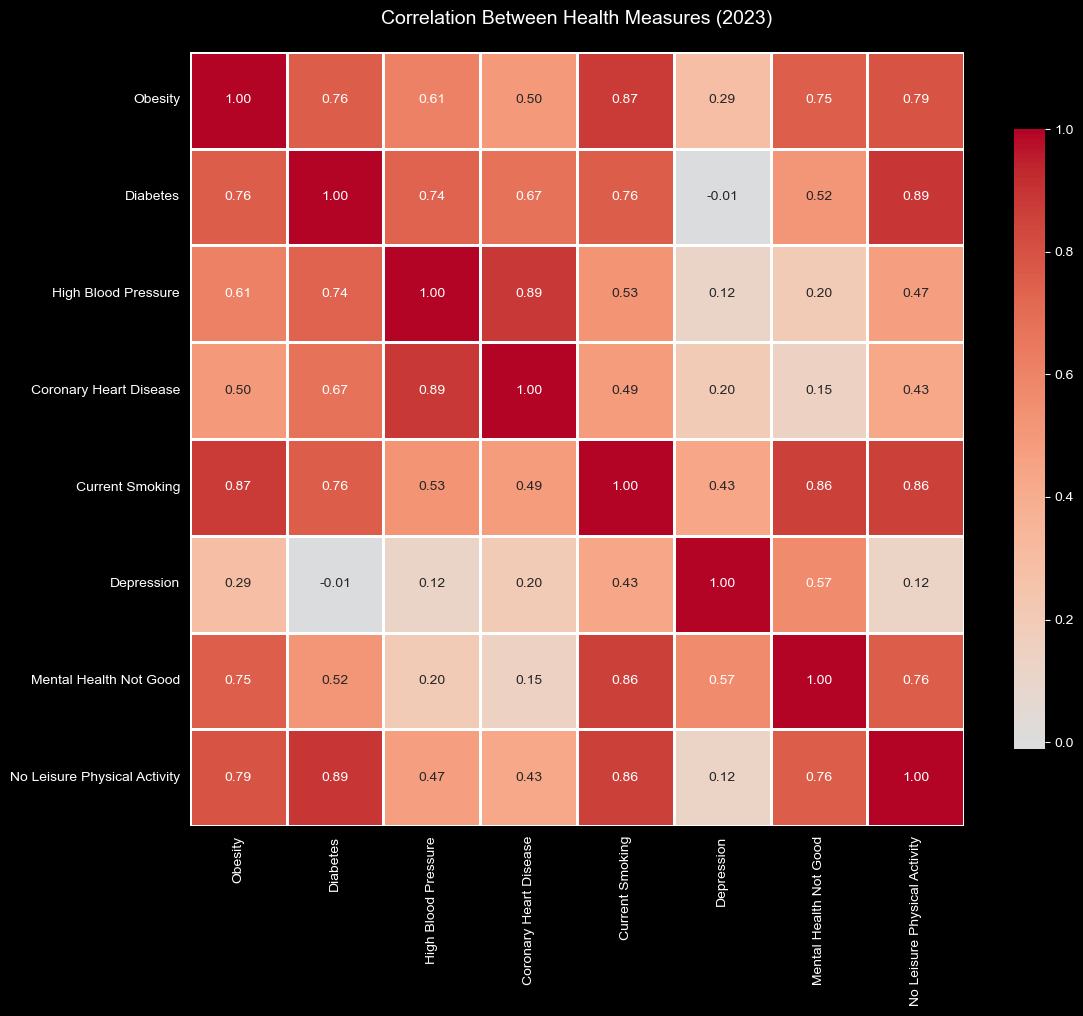

In [25]:
# Correlation matrix for health measures
if available_measures and len(available_measures) >= 4:
    measure_cols = list(available_measures.keys())
    corr_matrix = latest_data[measure_cols].corr()
    
    # Plot correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                xticklabels=[available_measures[col] for col in measure_cols],
                yticklabels=[available_measures[col] for col in measure_cols])
    ax.set_title(f'Correlation Between Health Measures ({latest_year})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

In [26]:
# Find strongest correlations
if available_measures and len(available_measures) >= 4:
    measure_cols = list(available_measures.keys())
    corr_matrix = latest_data[measure_cols].corr()
    
    print("\nStrongest Positive Correlations:")
    corr_pairs = []
    for i in range(len(measure_cols)):
        for j in range(i+1, len(measure_cols)):
            corr_pairs.append({
                'measure1': available_measures[measure_cols[i]],
                'measure2': available_measures[measure_cols[j]],
                'correlation': corr_matrix.iloc[i, j]
            })
    
    corr_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)
    display(corr_df.head(20))


Strongest Positive Correlations:


,measure1,measure2,correlation
12,Diabetes,No Leisure Physical Activity,0.894667
13,High Blood Pressure,Coronary Heart Disease,0.885321
3,Obesity,Current Smoking,0.874535
24,Current Smoking,No Leisure Physical Activity,0.861573
23,Current Smoking,Mental Health Not Good,0.858222
6,Obesity,No Leisure Physical Activity,0.791209
27,Mental Health Not Good,No Leisure Physical Activity,0.760887
9,Diabetes,Current Smoking,0.760197
0,Obesity,Diabetes,0.758734
5,Obesity,Mental Health Not Good,0.748190


## 7. Composite Health Index


Composite Health Burden Index
Based on: Obesity, Diabetes, High Blood Pressure, Current Smoking, Depression

Index Statistics:
count    587.000000
mean      19.588756
std        2.814823
min        8.180000
25%       17.580000
50%       19.500000
75%       21.240000
max       29.980000
Name: health_burden_index, dtype: float64

Healthiest ZCTAs (Lowest Burden):


,zcta,health_burden_index
961,08544,8.18
209,07311,10.12
207,07310,10.72
825,08240,10.98
197,07302,12.88
963,08550,13.48
131,07078,13.52
51,07030,13.70
979,08561,13.74
69,07041,13.80



ZCTAs with Highest Health Burden:


,zcta,health_burden_index
181,07114,29.98
777,08103,29.30
779,08104,27.98
901,08349,27.24
171,07108,27.20
293,07505,27.18
913,08401,27.10
775,08102,26.86
881,08329,26.74
677,08045,26.70


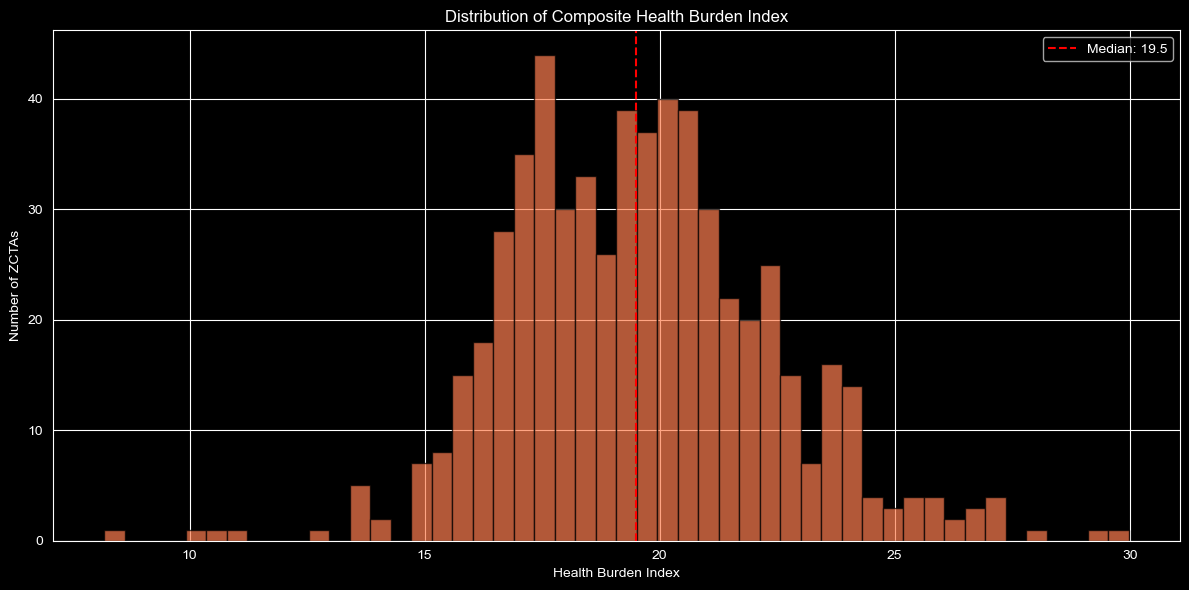

In [27]:
# Create a simple composite health index (average of key measures)
if available_measures and len(available_measures) >= 4:
    # Select measures for composite (higher = worse health)
    composite_measures = ['obesity', 'diabetes', 'bphigh', 'csmoking', 'depression']
    composite_measures = [m for m in composite_measures if m in available_measures]
    
    if composite_measures:
        latest_data['health_burden_index'] = latest_data[composite_measures].mean(axis=1)
        
        print(f"\nComposite Health Burden Index")
        print(f"Based on: {', '.join([available_measures[m] for m in composite_measures])}")
        print(f"\nIndex Statistics:")
        print(latest_data['health_burden_index'].describe())
        
        # Top and bottom ZCTAs
        print("\nHealthiest ZCTAs (Lowest Burden):")
        best_health = latest_data.nsmallest(10, 'health_burden_index')[['zcta', 'health_burden_index']]
        display(best_health)
        
        print("\nZCTAs with Highest Health Burden:")
        worst_health = latest_data.nlargest(10, 'health_burden_index')[['zcta', 'health_burden_index']]
        display(worst_health)
        
        # Distribution plot
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.hist(latest_data['health_burden_index'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
        ax.axvline(latest_data['health_burden_index'].median(), color='red', linestyle='--', 
                   label=f'Median: {latest_data["health_burden_index"].median():.1f}')
        ax.set_xlabel('Health Burden Index')
        ax.set_ylabel('Number of ZCTAs')
        ax.set_title('Distribution of Composite Health Burden Index')
        ax.legend()
        plt.tight_layout()
        plt.show()

<llm-progress-log-group></llm-progress-log-group>

<llm-progress-log-group></llm-progress-log-group>

In [28]:
# mean health burden index by county
# Since there's no county mapping table, we'll create one based on ZCTA prefixes
# NJ ZCTAs typically group by county regions

# Create approximate county grouping based on ZCTA prefixes
# Major NJ county regions by ZIP prefix
county_map = {
    '070': 'Essex/Hudson', '071': 'Bergen/Passaic',
    '072': 'Union/Morris', '073': 'Union/Middlesex',
    '074': 'Sussex/Passaic', '075': 'Bergen/Passaic',
    '076': 'Morris/Warren', '077': 'Somerset/Morris',
    '078': 'Hunterdon/Somerset', '079': 'Sussex/Warren',
    '080': 'Middlesex/Mercer', '081': 'Camden/Burlington',
    '082': 'Atlantic/Cape May', '083': 'Atlantic/Ocean',
    '084': 'Monmouth/Ocean', '085': 'Mercer/Monmouth',
    '086': 'Burlington/Monmouth', '087': 'Ocean',
    '088': 'Monmouth/Ocean', '089': 'Burlington/Ocean'
}

latest_data['county_region'] = latest_data['zcta'].astype(str).str[:3].map(county_map)

# Calculate mean health burden index by county region
county_stats = latest_data.groupby('county_region').agg({
    'health_burden_index': ['mean', 'count']
}).reset_index()
county_stats.columns = ['county_region', 'mean_hbi', 'num_zctas']
county_stats = county_stats.sort_values('mean_hbi', ascending=False)


# Display table
display(county_stats)


,county_region,mean_hbi,num_zctas
5,Camden/Burlington,23.568889,9
1,Atlantic/Ocean,23.493333,33
2,Bergen/Passaic,22.887500,24
17,Union/Morris,21.631429,7
0,Atlantic/Cape May,21.311111,27
9,Middlesex/Mercer,21.026667,84
12,Ocean,20.234400,25
3,Burlington/Monmouth,19.814667,15
4,Burlington/Ocean,19.393333,3
7,Hunterdon/Somerset,19.278571,42


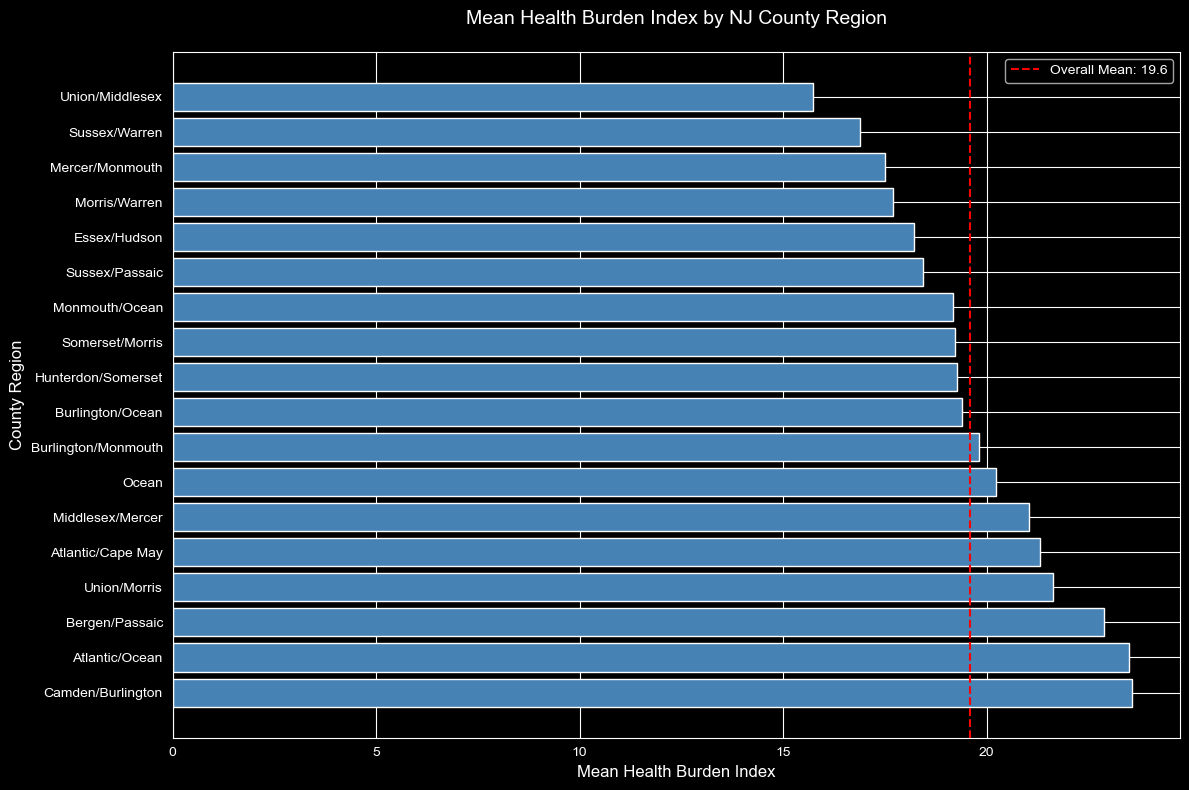

In [29]:
# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(county_stats['county_region'], county_stats['mean_hbi'], color='steelblue')
ax.set_xlabel('Mean Health Burden Index', fontsize=12)
ax.set_ylabel('County Region', fontsize=12)
ax.set_title('Mean Health Burden Index by NJ County Region', fontsize=14, pad=20)
ax.axvline(latest_data['health_burden_index'].mean(), color='red', linestyle='--',
           label=f'Overall Mean: {latest_data["health_burden_index"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Access to Care Measures

In [30]:
# Check for healthcare access measures
access_measures = {
    'access2': 'Lack of Health Insurance',
    'checkup': 'Annual Checkup',
    'dental': 'Dental Visit'
}

available_access = {k: v for k, v in access_measures.items() if k in latest_data.columns}

if available_access:
    print("\nHealthcare Access Measures:")
    for code, name in available_access.items():
        median_val = latest_data[code].median()
        if pd.notna(median_val):
            print(f"  • {name}: {median_val:.1f}% (median)")


Healthcare Access Measures:
  • Lack of Health Insurance: 8.1% (median)
  • Annual Checkup: 78.4% (median)


/opt/anaconda3/envs/nj-pipeline/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [31]:
# Get most recent year
latest_year = df['year'].max()
latest_data = df[df['year'] == latest_year].copy()

# Get health measures
id_cols = ['zcta', 'location_name', 'year']
health_measures = [col for col in df.columns if col not in id_cols]

# Create county mapping
county_map = {
    '070': 'Essex/Hudson', '071': 'Bergen/Passaic',
    '072': 'Union/Morris', '073': 'Union/Middlesex',
    '074': 'Sussex/Passaic', '075': 'Bergen/Passaic',
    '076': 'Morris/Warren', '077': 'Somerset/Morris',
    '078': 'Hunterdon/Somerset', '079': 'Sussex/Warren',
    '080': 'Middlesex/Mercer', '081': 'Camden/Burlington',
    '082': 'Atlantic/Cape May', '083': 'Atlantic/Ocean',
    '084': 'Monmouth/Ocean', '085': 'Mercer/Monmouth',
    '086': 'Burlington/Monmouth', '087': 'Ocean',
    '088': 'Monmouth/Ocean', '089': 'Burlington/Ocean'
}

latest_data['county_region'] = latest_data['zcta'].astype(str).str[:3].map(county_map)

# Calculate mean by county for all health measures
county_means = latest_data.groupby('county_region')[health_measures].mean()

print(f"Health Metrics Mean by County Region ({latest_year}):")
county_means


Health Metrics Mean by County Region (2023):


,access2,arthritis,bphigh,cancer,casthma,chd,checkup,cholscreen,copd,csmoking,...,diabetes,ghlth,highchol,lpa,mhlth,obesity,phlth,sleep,stroke,teethlost
county_region,,,,,,,,,,,,,,,,,,,,,
Atlantic/Cape May,8.540741,27.122222,35.992593,10.333333,9.474074,6.874074,80.444444,90.074074,6.307407,11.344444,...,11.025926,16.518519,43.300000,22.822222,14.896296,30.837037,13.000000,NaN,3.507407,NaN
Atlantic/Ocean,11.954545,25.842424,37.469697,8.251515,9.772727,6.690909,77.515152,87.639394,6.996970,15.466667,...,11.690909,20.036364,40.084848,27.454545,17.106061,35.448485,14.518182,NaN,3.657576,NaN
Bergen/Passaic,22.437500,20.212500,33.520833,4.837500,10.095833,6.004167,74.716667,84.716667,6.466667,15.929167,...,14.379167,27.470833,36.554167,36.541667,18.337500,34.804167,15.795833,NaN,4.000000,NaN
Burlington/Monmouth,14.673333,19.466667,30.900000,6.033333,9.466667,5.206667,76.700000,86.446667,5.246667,12.653333,...,11.106667,19.893333,34.900000,26.700000,16.526667,28.886667,12.640000,NaN,3.253333,NaN
Burlington/Ocean,14.633333,17.533333,29.466667,5.033333,9.000000,4.366667,76.100000,84.733333,4.266667,10.900000,...,10.233333,19.366667,34.166667,26.733333,16.366667,32.000000,11.466667,NaN,2.500000,NaN
Camden/Burlington,19.066667,23.377778,35.155556,5.877778,10.311111,6.211111,76.400000,85.422222,6.677778,16.400000,...,14.133333,25.588889,37.200000,33.744444,18.333333,34.377778,15.822222,NaN,3.988889,NaN
Essex/Hudson,11.302532,19.673418,30.111392,7.094937,8.753165,4.950633,77.372152,89.426582,4.443038,9.688608,...,9.781013,15.783544,38.316456,22.979747,14.310127,26.529114,11.277215,NaN,2.769620,NaN
Hunterdon/Somerset,8.285714,24.292857,32.876190,9.295238,9.100000,5.730952,78.333333,90.276190,5.185714,10.340476,...,9.395238,14.571429,40.128571,21.259524,14.359524,26.816667,11.673810,NaN,2.928571,NaN
Mercer/Monmouth,6.861290,21.664516,29.367742,8.083871,8.603226,4.887097,78.658065,90.112903,4.316129,8.883871,...,8.951613,12.945161,38.232258,19.312903,13.567742,25.209677,10.451613,NaN,2.548387,NaN


## 10. Key Findings Summary

In [32]:
print("="*70)
print("KEY FINDINGS - CDC PLACES HEALTH DATA")
print("="*70)

years = sorted(zcta_data['year'].unique())
print(f"\n1. COVERAGE")
print(f"   • {len(latest_data)} ZCTAs with health data in {latest_year}")
print(f"   • {len(available_measures)} key health measures available")
print(f"   • Years covered: {min(years)} - {max(years)}")

# Ensure 'trends' DataFrame is available for time series analysis
if 'trends' not in locals():
    trends = conn.execute("SELECT year, AVG(obesity) as obesity, AVG(diabetes) as diabetes, AVG(bphigh) as bphigh FROM cdc_places_wide GROUP BY year ORDER BY year").df().set_index('year')

if available_measures:
    print(f"\n2. PREVALENCE (Median % across ZCTAs in {latest_year})")
    for code, name in list(available_measures.items())[:6]:
        if code in latest_data.columns:
            median_val = latest_data[code].median()
            if pd.notna(median_val):
                print(f"   • {name}: {median_val:.1f}%")

if 'health_burden_index' in latest_data.columns:
    hbi_data = latest_data['health_burden_index'].dropna()
    if len(hbi_data) > 0:
        print(f"\n3. HEALTH BURDEN INDEX")
        print(f"   • Median index: {hbi_data.median():.1f}")
        print(f"   • Range: {hbi_data.min():.1f} - {hbi_data.max():.1f}")
        best = latest_data.nsmallest(1, 'health_burden_index').iloc[0]
        worst = latest_data.nlargest(1, 'health_burden_index').iloc[0]
        print(f"   • Healthiest ZCTA: {best['zcta']} ({best['health_burden_index']:.1f})")
        print(f"   • Highest burden: {worst['zcta']} ({worst['health_burden_index']:.1f})")

print("\n" + "="*70)

print(f"\n4. GEOGRAPHIC DISPARITIES (by ZCTA prefix region)")
if 'county_region' in latest_data.columns and not county_stats.empty:
    print(f"   • Regions with highest burden:")
    for _, row in county_stats.head(3).iterrows():
        print(f"     - {row['county_region']}: {row['mean_hbi']:.1f} (avg HBI)")
    print(f"   • Regions with lowest burden:")
    for _, row in county_stats.tail(3).iterrows():
        print(f"     - {row['county_region']}: {row['mean_hbi']:.1f} (avg HBI)")

print(f"\n5. CORRELATIONS")
if 'corr_df' in locals() and not corr_df.empty:
    print(f"   • Strongest positive correlation: {corr_df.iloc[0]['measure1']} and {corr_df.iloc[0]['measure2']} ({corr_df.iloc[0]['correlation']:.2f})")
    print(f"   • Other notable correlations:")
    for _, row in corr_df.iloc[1:4].iterrows():
        print(f"     - {row['measure1']} and {row['measure2']} ({row['correlation']:.2f})")

print(f"\n6. TIME SERIES (Median across ZCTAs)")
if len(years) > 1 and available_measures:
    print(f"   • Trends observed for {len(available_measures)} measures over {len(years)} years.")
    for measure_code, measure_name in list(available_measures.items())[:3]:
        if measure_code in trends.columns:
            start_val = trends.loc[min(years), measure_code]
            end_val = trends.loc[max(years), measure_code]
            change = end_val - start_val
            print(f"     - {measure_name}: {start_val:.1f}% in {min(years)} to {end_val:.1f}% in {max(years)} (Change: {change:.1f}pp)")

KEY FINDINGS - CDC PLACES HEALTH DATA

1. COVERAGE
   • 587 ZCTAs with health data in 2023
   • 8 key health measures available
   • Years covered: 2022 - 2023

2. PREVALENCE (Median % across ZCTAs in 2023)
   • Obesity: 28.2%
   • Diabetes: 9.8%
   • High Blood Pressure: 32.3%
   • Coronary Heart Disease: 5.5%
   • Current Smoking: 10.3%
   • Depression: 15.8%


4. GEOGRAPHIC DISPARITIES (by ZCTA prefix region)
   • Regions with highest burden:
     - Camden/Burlington: 23.6 (avg HBI)
     - Atlantic/Ocean: 23.5 (avg HBI)
     - Bergen/Passaic: 22.9 (avg HBI)
   • Regions with lowest burden:
     - Mercer/Monmouth: 17.5 (avg HBI)
     - Sussex/Warren: 16.9 (avg HBI)
     - Union/Middlesex: 15.7 (avg HBI)

5. CORRELATIONS
   • Strongest positive correlation: Diabetes and No Leisure Physical Activity (0.89)
   • Other notable correlations:
     - High Blood Pressure and Coronary Heart Disease (0.89)
     - Obesity and Current Smoking (0.87)
     - Current Smoking and No Leisure Physical

In [33]:
conn.close()


## 11. Next Steps

Based on this initial EDA, here are some potential next steps:

1.  **Refine County Mapping:** The current ZCTA prefix-based county mapping is a rough approximation. Integrate a more precise ZCTA-to-county mapping (e.g., using HUD's USPS ZIP Code Crosswalk Files or other census data) to get accurate county-level statistics.
2.  **Spatial Analysis:**
    *   Visualize health measures on a map of NJ ZCTAs to identify spatial clusters of high or low prevalence.
    *   Use spatial autocorrelation (e.g., Moran's I) to quantify the degree of clustering.
3.  **Regression Analysis:**
    *   Explore relationships between health measures and socioeconomic factors (e.g., poverty, education, income) from census data.
    *   Identify predictors of high health burden.
4.  **Deep Dive into Specific ZCTAs:**
    *   Investigate the characteristics of the "healthiest" and "highest burden" ZCTAs identified by the composite index.
    *   Look for commonalities or unique factors in these areas.
5.  **Policy Implications:**
    *   Based on findings, suggest potential public health interventions or policy changes. For example, if certain regions consistently show high rates of diabetes and obesity, targeted programs for healthy eating and physical activity could be recommended.
6.  **Interactive Dashboard:**
    *   Develop an interactive dashboard (e.g., using Plotly Dash or Streamlit) to allow stakeholders to explore the data, filter by ZCTA or measure, and visualize trends.
7.  **Data Integration:**
    *   Integrate other relevant datasets, such as environmental data (e.g., air quality, access to green spaces), food access data (e.g., food deserts), or healthcare facility locations, to provide a more holistic view of health determinants.
8.  **Causality Exploration:**
    *   While correlation analysis is useful, further research could explore potential causal links between different health behaviors and outcomes.

This EDA provides a strong foundation for understanding health patterns in New Jersey. The next steps would involve moving from descriptive analysis to more inferential and predictive modeling, ultimately aiming to inform actionable public health strategies.


<llm-progress-log-group></llm-progress-log-group>

In [34]:





)

SyntaxError: unmatched ')' (4073138091.py, line 1)